In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import missingno as msno

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split


In [123]:
# Загрузим данные SKEMPI_2 
data = pd.read_csv('data/skempi_v2.csv', sep=';')  
data

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_mut_parsed,koff_wt (s^(-1)),koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,3QIB_ABP_CD,KP9R,KP8R,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,...,0.500,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7081,3QIB_ABP_CD,TP12A,TP11A,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SPR,2
7082,3QIB_ABP_CD,TP12S,TP11S,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,...,0.134,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2
7083,3QIB_ABP_CD,TP12N,TP11N,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",4.34E-05,4.340000e-05,5.5E-06,5.500000e-06,...,0.175,2.2E-02,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2


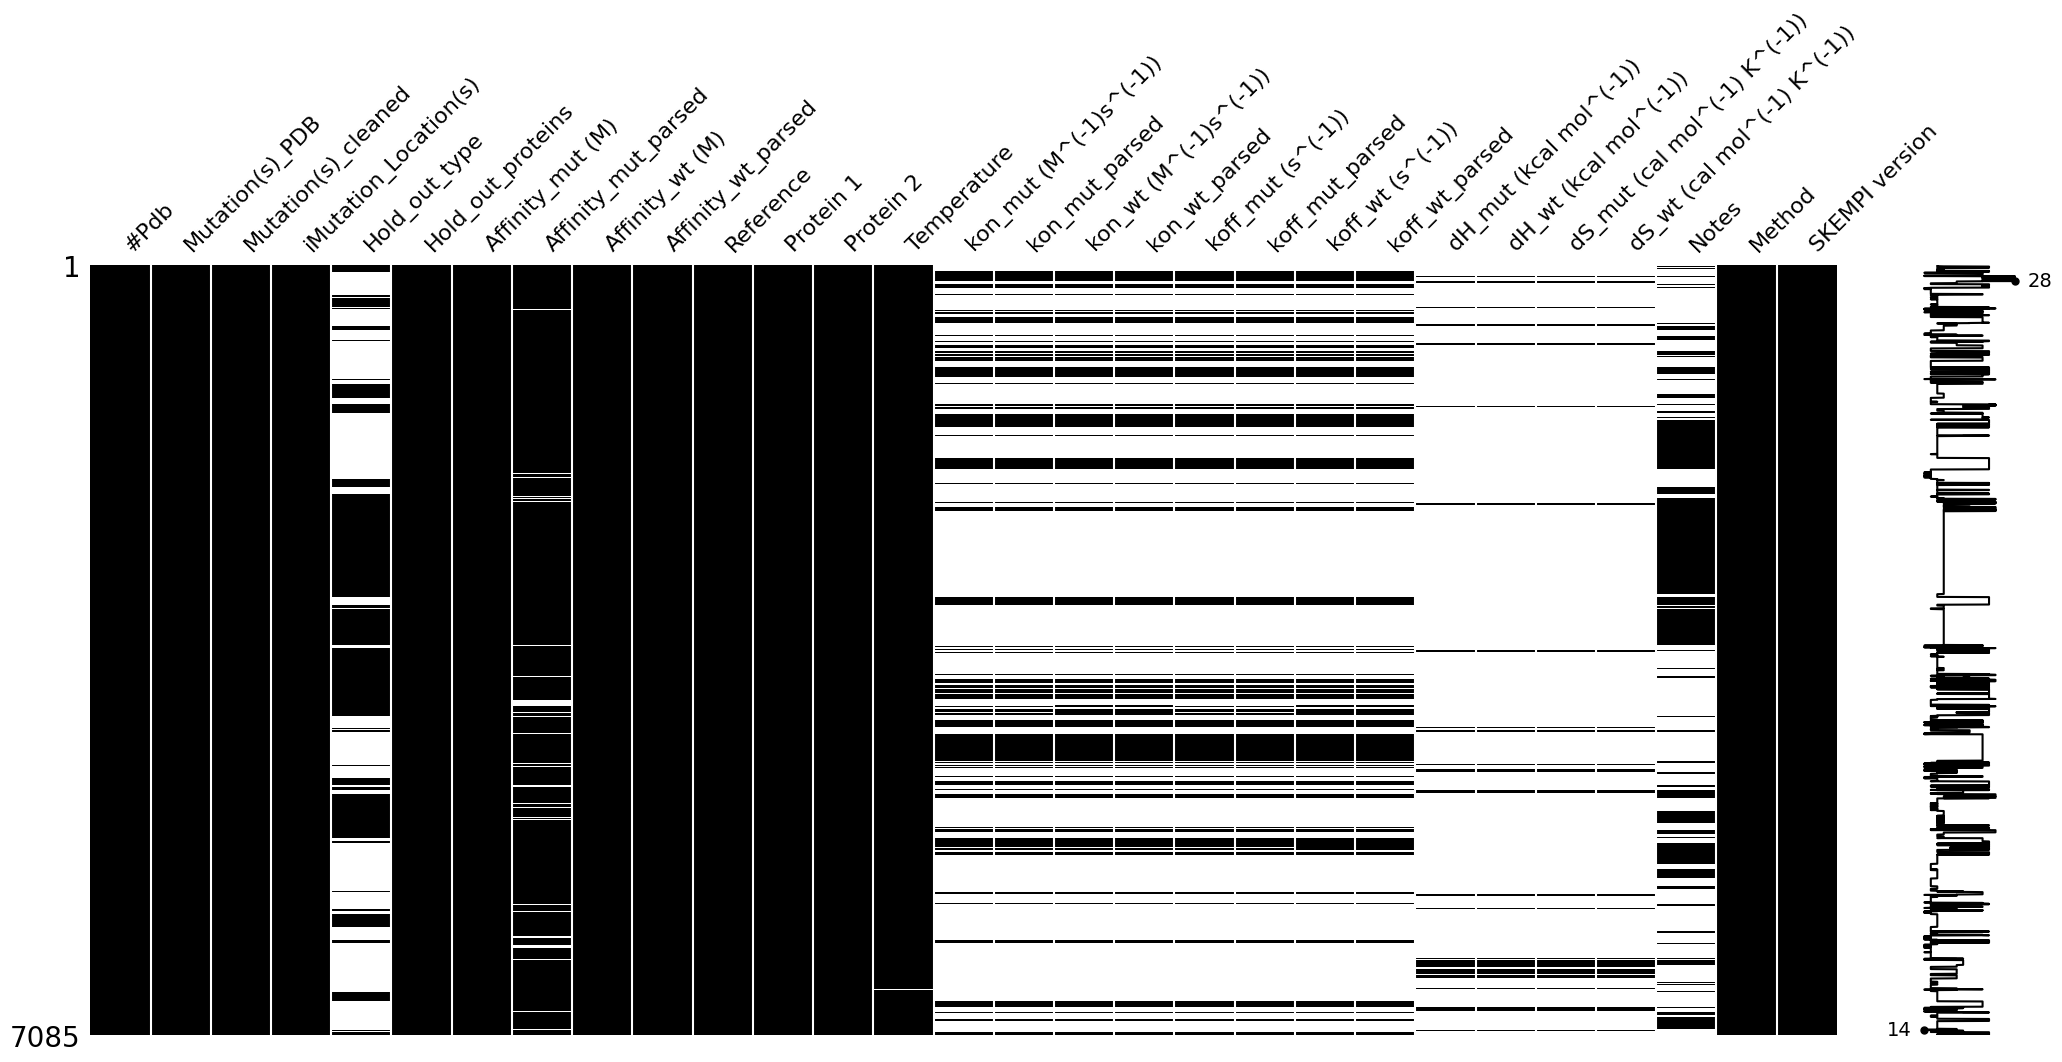

In [124]:
# рассмотрим пропуски в данных до обработки
# Отобразим матрицу для выявления пропусков
msno.matrix(data, color=(0, 0, 0)) 
plt.show()

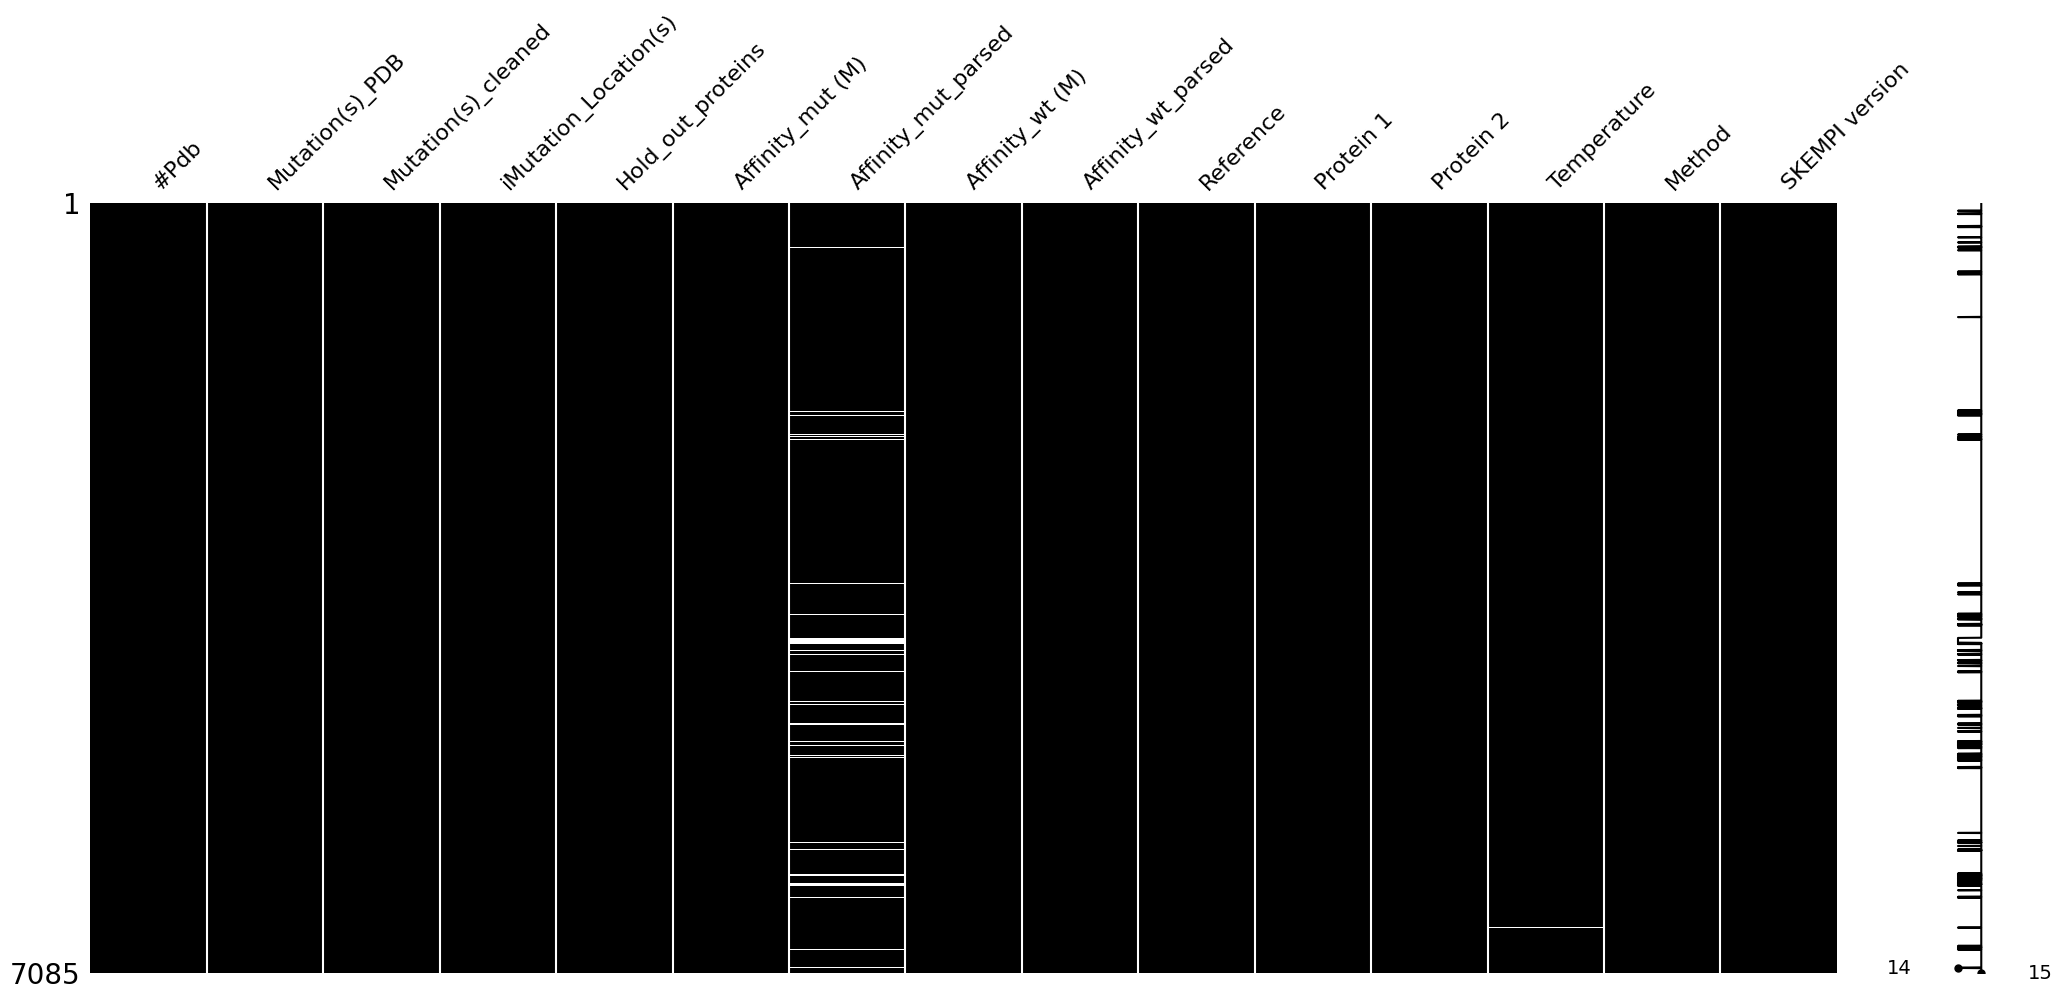

In [ ]:
# Вычислим сколько пропущено значений в каждом признаке и удалим столбцы, где пропусков более 10%, так как более 10-20% значений вручную восстановить нельзя
mis_perc = data.isnull().mean() * 100
columns_to_drop = mis_perc[mis_perc > 10].index
data_cl = data.drop(columns=columns_to_drop)

# Отобразим матрицу для выявления пропусков
msno.matrix(data_cl, color=(0, 0, 0)) 
plt.show()

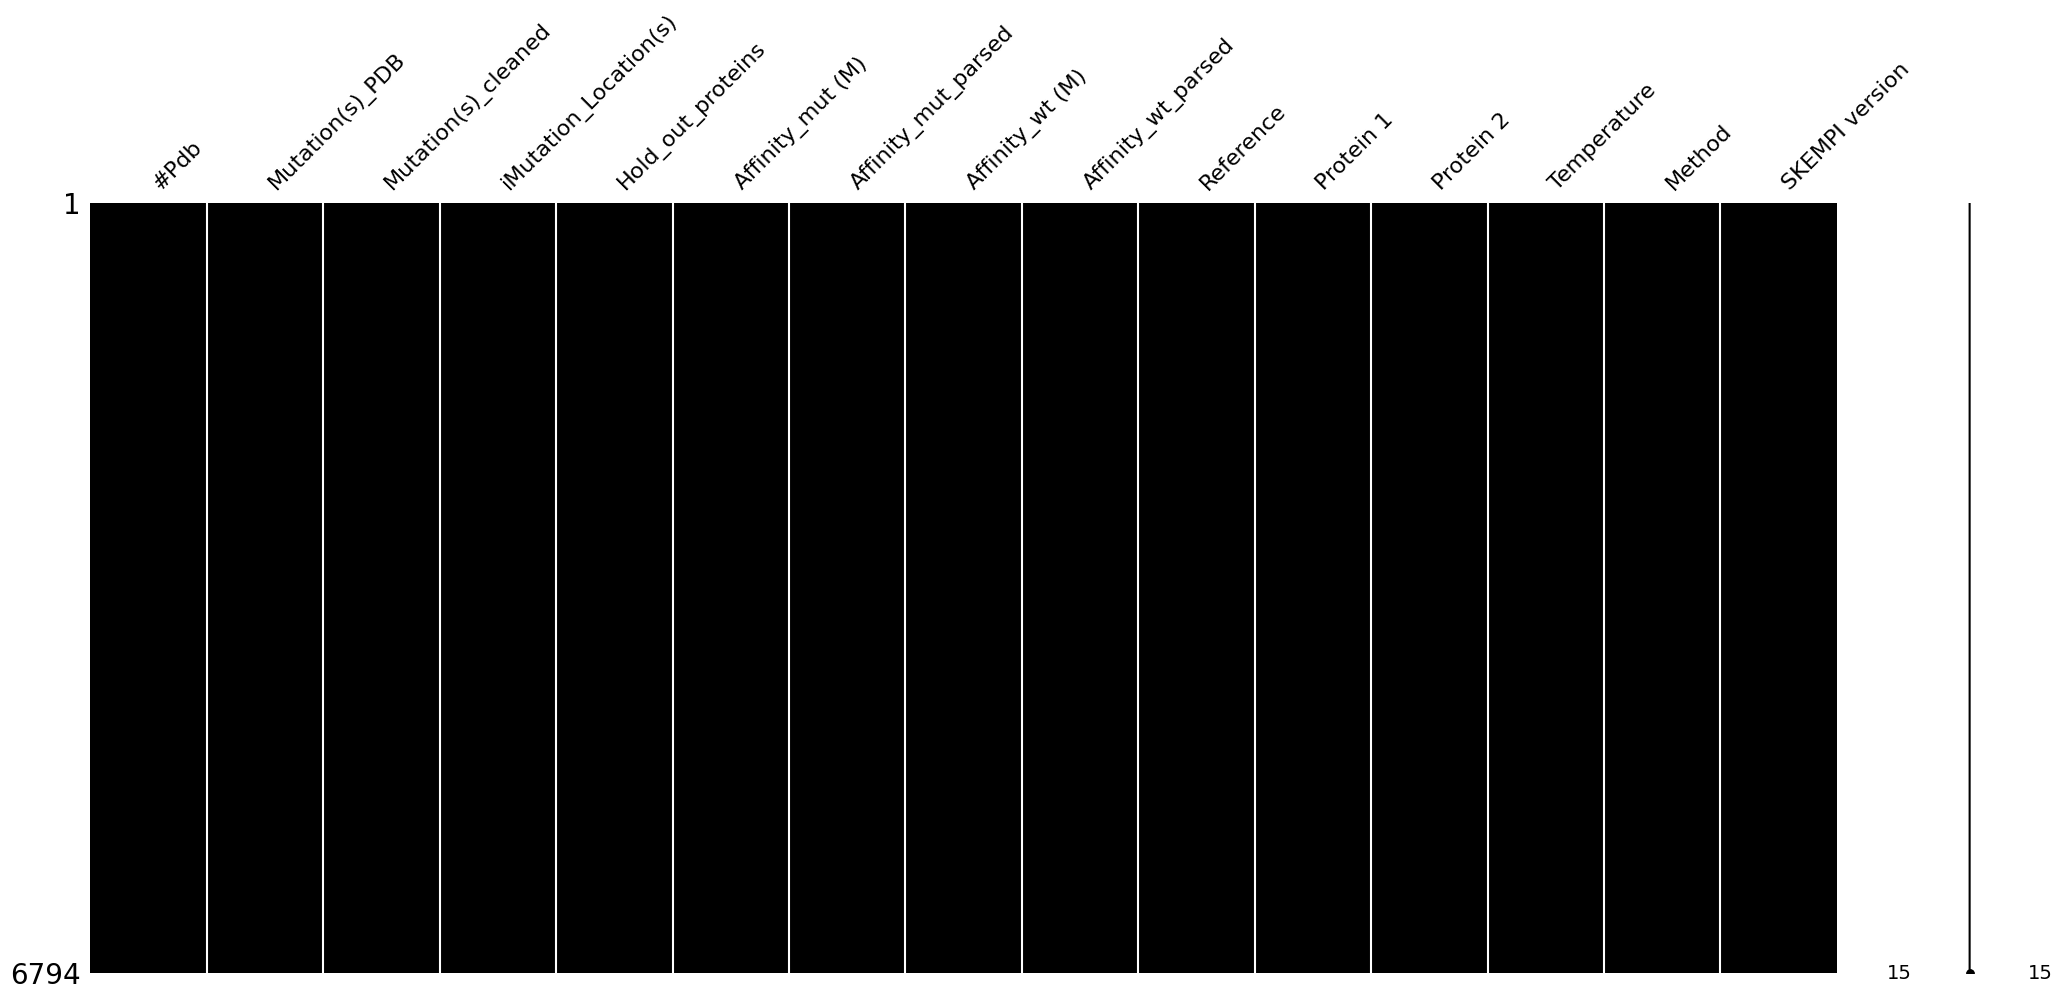

In [126]:
# Так как теперь осталось мало строк с пропусками, мы можем удалить все строки с пропущенными значениями во всем датасете
data_cl_10 = data_cl.dropna()

# Отобразим матрицу для выявления пропусков
msno.matrix(data_cl_10, color=(0, 0, 0)) 
plt.show()

In [127]:
data_cl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   #Pdb                   7085 non-null   object 
 1   Mutation(s)_PDB        7085 non-null   object 
 2   Mutation(s)_cleaned    7085 non-null   object 
 3   iMutation_Location(s)  7085 non-null   object 
 4   Hold_out_proteins      7085 non-null   object 
 5   Affinity_mut (M)       7085 non-null   object 
 6   Affinity_mut_parsed    6800 non-null   float64
 7   Affinity_wt (M)        7085 non-null   object 
 8   Affinity_wt_parsed     7083 non-null   float64
 9   Reference              7085 non-null   object 
 10  Protein 1              7085 non-null   object 
 11  Protein 2              7085 non-null   object 
 12  Temperature            7081 non-null   object 
 13  Method                 7085 non-null   object 
 14  SKEMPI version         7085 non-null   int64  
dtypes: f

In [128]:
# Самостоятельно преобразуем значения столбцов Affinity_mut (M) и Affinity_wt (M) типа object в float
data_cl['Affinity_mut (M)'] = pd.to_numeric(data_cl['Affinity_mut (M)'], errors='coerce') # они же скорее всего Affinity_mut_parsed, но так как я не могу проверить качественность преобразования, решила сама провести преобразования object в float
data_cl['Affinity_wt (M)'] = pd.to_numeric(data_cl['Affinity_wt (M)'], errors='coerce') # аналогично как и в Affinity_mut_parsed

# Проверим, если после преобразования есть NaN, это нам поможет определить значения NaN, которые могли быть обозначены каким-то другим значением != NaN
data_cl.dropna(subset=['Affinity_mut (M)', 'Affinity_wt (M)'], inplace=True)

# Теперь можно рассчитать ddG
RT = 0.001987 * 298  # R, T - общепризнанные константы для вычисления свободной энергии связывания
data_cl['ddG'] = RT * (np.log(data_cl['Affinity_mut (M)']) - np.log(data_cl['Affinity_wt (M)']))


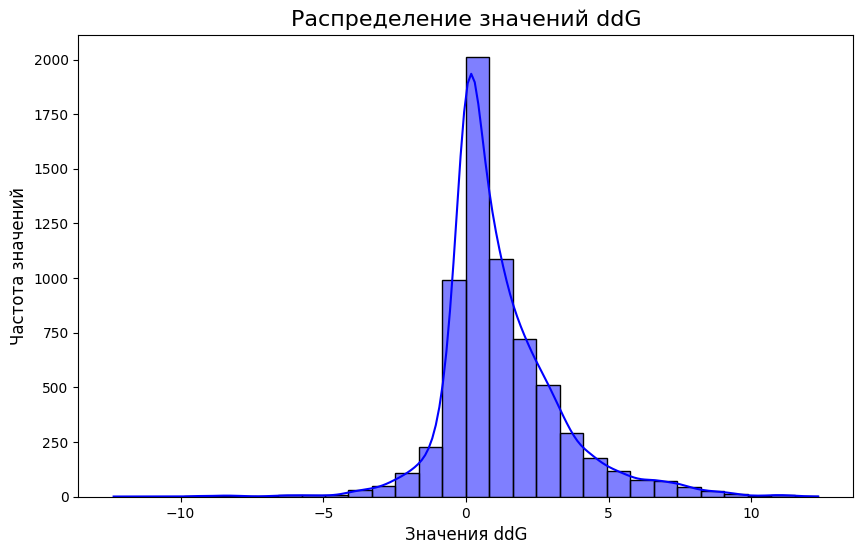

In [129]:
# Получив числовые значеня ddG мы можем посмотреть распределение значений 
plt.figure(figsize=(10, 6))
sns.histplot(data_cl['ddG'], kde=True, bins=30, color='blue')
plt.title('Распределение значений ddG', fontsize=16)
plt.xlabel('Значения ddG', fontsize=12)
plt.ylabel('Частота значений', fontsize=12)
plt.show()


In [130]:
# Рассмотрим квантили 25 и 75 у ddG чтобы понять дисперсию выбросов
data_cl.describe()

,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,SKEMPI version,ddG
count,6.611000e+03,6.611000e+03,6.611000e+03,6.611000e+03,6611.000000,6611.000000
mean,2.579710e-05,2.579710e-05,2.029420e-06,2.029420e-06,1.544244,1.200319
std,5.929816e-04,5.929816e-04,2.028156e-05,2.028156e-05,0.498076,2.056813
min,2.000000e-16,2.000000e-16,3.300000e-16,3.300000e-16,1.000000,-12.345430
25%,5.300000e-10,5.300000e-10,9.400000e-11,9.400000e-11,1.000000,0.023934
50%,1.560000e-08,1.560000e-08,2.500000e-09,2.500000e-09,2.000000,0.723313
75%,1.000000e-06,1.000000e-06,6.000000e-08,6.000000e-08,2.000000,2.076324
max,4.050000e-02,4.050000e-02,6.350000e-04,6.350000e-04,2.000000,12.345430


In [ ]:
# Дисперсия 25% и min очень большая, возможно это ошибка в данных, но так как нам нужен лишь знак изменения энергии, то это не имеет большого значения,
# потому что далее мы будет классифицировать на положительное и отрицательное
# Подсчитаем количество положительных и отрицательных значений
positive_ddG = (data_cl['ddG'] > 0).sum()
negative_ddG = (data_cl['ddG'] < 0).sum()

# Получили соотношение
total = positive_ddG + negative_ddG
positive_ratio = positive_ddG / total
negative_ratio = negative_ddG / total

print(f"Положительные значения (ddG): {positive_ddG} ({positive_ratio:.2f})")
print(f"Отрицательные значения (ddG): {negative_ddG} ({negative_ratio:.2f})")


Положительные значения (ddG): 4989 (0.78)
Отрицательные значения (ddG): 1444 (0.22)


In [132]:
# Обновляем целевую переменную в самом датасете
data_cl['ddG'] = data_cl['ddG'].apply(lambda x: 1 if x >= 0 else -1)

In [133]:
# Перед обучением модели проверим на пропуски в данных
nan_rows = data_cl[data_cl.isna().any(axis=1)]
nan_rows


,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,Reference,Protein 1,Protein 2,Temperature,Method,SKEMPI version,ddG
6665,4G0N_A_B,DA38A,DA38A,COR,"4G0N_A_B,3KUD_A_B,1LFD_A_B,1GUA_A_B,1C1Y_A_B,1...",1.300000e-06,1.300000e-06,1.800000e-08,1.800000e-08,8636102,H-Ras1,Raf-RBD,NaN,IAFL,2,1
6668,1LFD_A_B,YB232W,YB32W,SUR,"1LFD_A_B,4G0N_A_B,3KUD_A_B,1K8R_A_B,1HE8_A_B,1...",7.000000e-07,7.000000e-07,1.000000e-06,1.000000e-06,8636102,RalGDS-RBD,H-Ras1,NaN,IAFL,2,-1


In [134]:
# Видим пропуски в температуре, удалим их
data_cl = data_cl.dropna()

nan_rows = data_cl[data_cl.isna().any(axis=1)]
nan_rows


,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,Reference,Protein 1,Protein 2,Temperature,Method,SKEMPI version,ddG


In [135]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, precision_score, recall_score
# Для обучения модели разделим данные на общие данные и на целевой признак, а после на тренировочную и тестовую выборки 
X = data_cl.drop(columns =['ddG', 'Affinity_mut (M)',	'Affinity_mut_parsed',	'Affinity_wt (M)',	'Affinity_wt_parsed'], axis=1)  # Удалим признаки напрямую связанные с ddG
y = data_cl['ddG']  

# Так как у нас много столбцов с категориальными признаками, используем модель CatBoosting, которая отлично умеет с ними работать
categorical_columns = X.select_dtypes(include=['object']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Указываем базовую настройку модели
model = CatBoostClassifier(iterations=1000, 
                           depth=6, 
                           learning_rate=0.1, 
                           loss_function='Logloss', 
                           cat_features=categorical_columns.tolist(),  # Указываем строковые столбцы как категориальные
                           verbose=100)

# Обучаем
model.fit(X_train, y_train)

# Получаем предсказания
y_pred = model.predict(X_test)


0:	learn: 0.6449269	total: 45.4ms	remaining: 45.3s
100:	learn: 0.3610276	total: 4.76s	remaining: 42.3s
200:	learn: 0.3215072	total: 9.54s	remaining: 37.9s
300:	learn: 0.2902574	total: 14.2s	remaining: 33s
400:	learn: 0.2642490	total: 19s	remaining: 28.4s
500:	learn: 0.2425778	total: 23.7s	remaining: 23.6s
600:	learn: 0.2244253	total: 28.4s	remaining: 18.9s
700:	learn: 0.2079989	total: 33.2s	remaining: 14.2s
800:	learn: 0.1932497	total: 37.9s	remaining: 9.42s
900:	learn: 0.1798407	total: 42.6s	remaining: 4.68s
999:	learn: 0.1677426	total: 47.4s	remaining: 0us


In [136]:
# Оценим качество модели
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# F1-Score
f1 = f1_score(y_test, y_pred)
print(f'F1-Score: {f1:.2f}')

# Precision
precision = precision_score(y_test, y_pred)
print(f'Precision: {precision:.2f}')

# Recall
recall = recall_score(y_test, y_pred)
print(f'Recall: {recall:.2f}')

Accuracy: 0.84
F1-Score: 0.90
Precision: 0.87
Recall: 0.95


## Результаты обучения модели CatBoostClassifier

После обучения модели **CatBoostClassifier** можно сказать, что результаты в целом хорошие.  
Точность получилась около **84%**, а **F1-мера — 0.90**, что говорит о достаточно уверенном качестве классификации.

Особенно радует высокий **recall (95%)** — это значит, что модель почти не пропускает важные объекты,  
и если что-то нужно обязательно найти, она с этим справляется.

**Precision** тоже на уровне (**87%**), то есть большинство найденных "положительных" случаев действительно оказываются правильными.

---

Понятно, что модель ещё можно доработать — например:
- поиграть с параметрами,
- попробовать чуть лучше подготовить данные,  
особенно если нужно повысить точность.

Но даже в текущем виде она уже даёт **стабильный результат** и может использоваться как **базовое решение**.
